# Whisper-small — финальная модель на полных данных

In [7]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import WhisperModel, WhisperProcessor

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold

train_utils.set_seed(config.RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"GPU: {torch.cuda.get_device_name(device)}")

Device: cuda
GPU: NVIDIA GeForce RTX 2070


In [8]:
# Загружаем ВСЕ данные без выделения тестовой выборки
paths_all, labels_all, df_all = data_utils.load_dataset_csv()

# Порядок признаков должен точно совпадать с тем, что отправляет ml_api/main.py:
#   json.loads(letters) + [duration, n_speakers]
# letters = [has_л, has_р, has_с, has_т, has_ц, has_ч, has_ш, has_щ]
FEATURE_COLS = ["л", "р", "с", "т", "ц", "ч", "ш", "щ", "duration", "n_speakers"]
letters_all = df_all[FEATURE_COLS].values.astype(np.float32)

print(f"Всего записей: {len(paths_all)}")
print(f"  good={int((labels_all == 0).sum())}  bad={int((labels_all == 1).sum())}")
print(f"Признаки ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# 10% — внутренний val только для early stopping; в продакшн-оценку не входит
idx = np.arange(len(paths_all))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.10, stratify=labels_all, random_state=config.RANDOM_STATE
)
paths_train,  paths_val  = paths_all[idx_tr],  paths_all[idx_val]
labels_train, labels_val = labels_all[idx_tr], labels_all[idx_val]
letters_train, letters_val = letters_all[idx_tr], letters_all[idx_val]

print(f"\nTrain: {len(paths_train)}  Val(early-stop): {len(paths_val)}")

Всего записей: 2772
  good=1875  bad=897
Признаки (10): ['л', 'р', 'с', 'т', 'ц', 'ч', 'ш', 'щ', 'duration', 'n_speakers']

Train: 2494  Val(early-stop): 278


In [9]:
MODEL_ID = "openai/whisper-small"
processor = WhisperProcessor.from_pretrained(MODEL_ID)


class WhisperDataset(Dataset):
    def __init__(self, paths, labels, letters, augment=False):
        self.paths = paths
        self.labels = labels
        self.letters = letters
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        y, sr = data_utils.load_audio(self.paths[i], sr=16000)
        feats = processor.feature_extractor(
            y, sampling_rate=16000, return_tensors="np"
        ).input_features[0]
        if self.augment:
            feats = data_utils.augment_mel_spectrogram(feats)
        return (
            torch.from_numpy(feats).float(),
            torch.from_numpy(self.letters[i]).float(),
            int(self.labels[i]),
        )


BATCH_SIZE = 8
train_loader = DataLoader(
    WhisperDataset(paths_train, labels_train, letters_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    WhisperDataset(paths_val, labels_val, letters_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type == "cuda"),
)
print(f"Батчей train: {len(train_loader)}  val: {len(val_loader)}")

Батчей train: 312  val: 35


In [10]:
N_UNFREEZE = 4
EMBED_DIM  = 768
DROPOUT    = 0.3
N_EPOCHS   = 30


class WhisperClassifier(nn.Module):
    def __init__(self, whisper_model, n_letters=0, dropout=DROPOUT, n_unfreeze=N_UNFREEZE):
        super().__init__()
        self.encoder = whisper_model.encoder
        self.n_letters = n_letters

        for p in self.encoder.parameters():
            p.requires_grad = False

        n_layers = len(self.encoder.layers)
        for layer in self.encoder.layers[n_layers - n_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.encoder.layer_norm.parameters():
            p.requires_grad = True

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(EMBED_DIM + n_letters, 2)

        n_frozen = sum(not p.requires_grad for p in self.encoder.parameters())
        n_train  = sum(p.requires_grad for p in self.parameters())
        print(f"Encoder заморожено: {n_frozen}  |  Обучаемых параметров: {n_train:,}")

    def forward(self, input_features, letters=None):
        hidden = self.encoder(input_features).last_hidden_state
        pooled = self.dropout(hidden.mean(dim=1))
        if self.n_letters > 0 and letters is not None:
            pooled = torch.cat([pooled, letters], dim=1)
        return self.head(pooled)


whisper_model = WhisperModel.from_pretrained(MODEL_ID)
n_letters = letters_train.shape[1]
model = WhisperClassifier(whisper_model, n_letters=n_letters).to(device)

n_params_total     = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего: {n_params_total:,}  |  Обучаемых: {n_params_trainable:,}")

Encoder заморожено: 125  |  Обучаемых параметров: 64
Всего: 88,155,670  |  Обучаемых: 28,351,510


In [11]:
TARGET_LR_ENCODER = 2.5e-6
N_WARMUP_EPOCHS   = 2

weights   = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))

encoder_params = [p for n, p in model.named_parameters() if p.requires_grad and "head" not in n]
head_params    = list(model.head.parameters())
optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": TARGET_LR_ENCODER, "weight_decay": 1e-3},
    {"params": head_params,    "lr": 1e-4,              "weight_decay": 1e-4},
])
scheduler      = train_utils.get_lr_scheduler(optimizer)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt_path = exp_dir / "best_ckpt.pt"

warmup_steps = N_WARMUP_EPOCHS * len(train_loader)
best_f1      = -1.0
global_step  = 0
train_losses, val_f1s = [], []


def eval_loader(loader):
    model.eval()
    logits_list, true_list = [], []
    with torch.no_grad():
        for feats, letters, y in loader:
            logits = model(feats.to(device), letters.to(device))
            logits_list.append(logits.cpu().numpy())
            true_list.extend(y.tolist())
    logits = np.concatenate(logits_list)
    proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
    return proba, np.array(true_list)


t0 = time.perf_counter()

for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    for feats, letters, y in train_loader:
        if global_step < warmup_steps:
            optimizer.param_groups[0]["lr"] = TARGET_LR_ENCODER * (global_step + 1) / warmup_steps

        feats, letters, y = feats.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(feats, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        global_step += 1
        losses.append(loss.item())

    train_loss = np.mean(losses)
    train_losses.append(train_loss)

    val_proba, val_true = eval_loader(val_loader)
    opt_thr = find_optimal_threshold(val_true, val_proba)
    from sklearn.metrics import f1_score as _f1
    val_f1 = _f1(val_true, (val_proba >= opt_thr).astype(int),
                 pos_label=config.CLASS_BAD, average="binary")
    val_f1s.append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt_path)

    if global_step > warmup_steps:
        scheduler.step(val_f1)

    print(f"Epoch {epoch+1:2d}/{N_EPOCHS}  loss={train_loss:.4f}  "
          f"val_f1_bad={val_f1:.4f}  thr={opt_thr:.2f}  "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break

train_time_sec = time.perf_counter() - t0
train_utils.load_best_checkpoint(model, best_ckpt_path, device)
print(f"\nОбучение: {train_time_sec:.1f} с | best val_f1_bad={best_f1:.4f}")

Epoch  1/30  loss=0.6222  val_f1_bad=0.6381  thr=0.50  lr=1.25e-06
Epoch  2/30  loss=0.5695  val_f1_bad=0.6732  thr=0.44  lr=2.50e-06
Epoch  3/30  loss=0.5182  val_f1_bad=0.7527  thr=0.42  lr=2.50e-06
Epoch  4/30  loss=0.4736  val_f1_bad=0.7771  thr=0.48  lr=2.50e-06
Epoch  5/30  loss=0.4325  val_f1_bad=0.7957  thr=0.28  lr=2.50e-06
Epoch  6/30  loss=0.4103  val_f1_bad=0.8063  thr=0.36  lr=2.50e-06
Epoch  7/30  loss=0.3745  val_f1_bad=0.7958  thr=0.19  lr=2.50e-06
Epoch  8/30  loss=0.3366  val_f1_bad=0.7938  thr=0.12  lr=2.50e-06
Epoch  9/30  loss=0.3327  val_f1_bad=0.7789  thr=0.19  lr=2.50e-06
Epoch 10/30  loss=0.3052  val_f1_bad=0.7910  thr=0.48  lr=2.50e-06
Epoch 11/30  loss=0.2749  val_f1_bad=0.7816  thr=0.16  lr=2.50e-06
Epoch 12/30  loss=0.2791  val_f1_bad=0.7614  thr=0.28  lr=1.25e-06
Epoch 13/30  loss=0.2174  val_f1_bad=0.7746  thr=0.11  lr=1.25e-06
Epoch 14/30  loss=0.2354  val_f1_bad=0.7456  thr=0.11  lr=1.25e-06
Epoch 15/30  loss=0.2161  val_f1_bad=0.7456  thr=0.10  lr=1.25

In [12]:
# Пересчитываем оптимальный порог на val-выборке текущей модели
val_proba_final, val_true_final = eval_loader(val_loader)
production_threshold = find_optimal_threshold(val_true_final, val_proba_final)
print(f"Оптимальный порог (val 10%): {production_threshold:.2f}")

threshold_path = exp_dir / "threshold.json"
with open(threshold_path, "w") as f:
    json.dump({"threshold": float(production_threshold)}, f)

print(f"Порог сохранён: {threshold_path}")

Оптимальный порог (val 10%): 0.36
Порог сохранён: /mnt/d/Projects/HSE/VKR/HSE_VKR_DetectingSpeechDefects/experiments/08_final_model/exp_whisper_small_fulldata/threshold.json


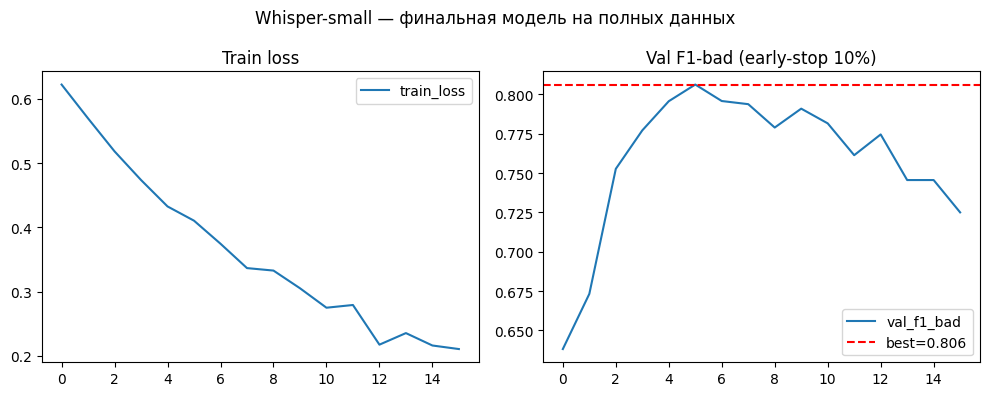

best_ckpt.pt: /mnt/d/Projects/HSE/VKR/HSE_VKR_DetectingSpeechDefects/experiments/08_final_model/exp_whisper_small_fulldata/best_ckpt.pt
threshold.json: /mnt/d/Projects/HSE/VKR/HSE_VKR_DetectingSpeechDefects/experiments/08_final_model/exp_whisper_small_fulldata/threshold.json

Для деплоя скопировать оба файла в models/whisper_small_finetuned/


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train_loss")
axes[0].set_title("Train loss")
axes[0].legend()
axes[1].plot(val_f1s, label="val_f1_bad")
axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}")
axes[1].set_title("Val F1-bad (early-stop 10%)")
axes[1].legend()
plt.suptitle("Whisper-small — финальная модель на полных данных")
plt.tight_layout()
fig.savefig(exp_dir / "training_curves.png", dpi=120)
plt.show()
print(f"best_ckpt.pt: {best_ckpt_path}")
print(f"threshold.json: {threshold_path}")
print(f"\nДля деплоя скопировать оба файла в models/whisper_small_finetuned/")